O que essa abordagem faz?
class_weight='balanced': Ajusta os pesos internamente para que o modelo não chute a classe majoritária com tanta facilidade só porque ela tem mais exemplos.

precision_recall_curve e F1-Score: Em vez de aceitar o padrão estrito de 0.5, o código varre os limiares possíveis e escolhe aquele que maximiza o equilíbrio entre acertar quem é da classe 1 (recall) e não disparar alarmes falsos (precisão).

Tente rodar esse trecho no seu ambiente para ver se a precisão da Classe 1 sobe sem prejudicar tanto o desempenho geral!

In [8]:
#Importando os pacotes das bibliotecas

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    roc_auc_score, 
    roc_curve, 
    confusion_matrix, 
    f1_score, 
    precision_score, 
    recall_score, 
    precision_recall_curve
)

X_train shape: (5634, 30)
X_test shape: (1409, 30)

[Treinamento] Ajustando Regressão Logística com StandardScaler e class_weight='balanced'...

 Melhor limiar (threshold) encontrado pelo F1-Score: 0.4360

=== COMPARATIVO DE MÉTRICAS ===
Limiar Padrão (0.50)   -> F1-Score: 0.5409 | Precisão: 0.4327 | Recall: 0.7212
Limiar Otimizado (0.44) -> F1-Score: 0.5540 | Precisão: 0.4272 | Recall: 0.7879

=== RELATÓRIO DE CLASSIFICAÇÃO (LIMIAR OTIMIZADO) ===
              precision    recall  f1-score   support

           0       0.79      0.43      0.55       914
           1       0.43      0.79      0.55       495

    accuracy                           0.55      1409
   macro avg       0.61      0.61      0.55      1409
weighted avg       0.66      0.55      0.55      1409



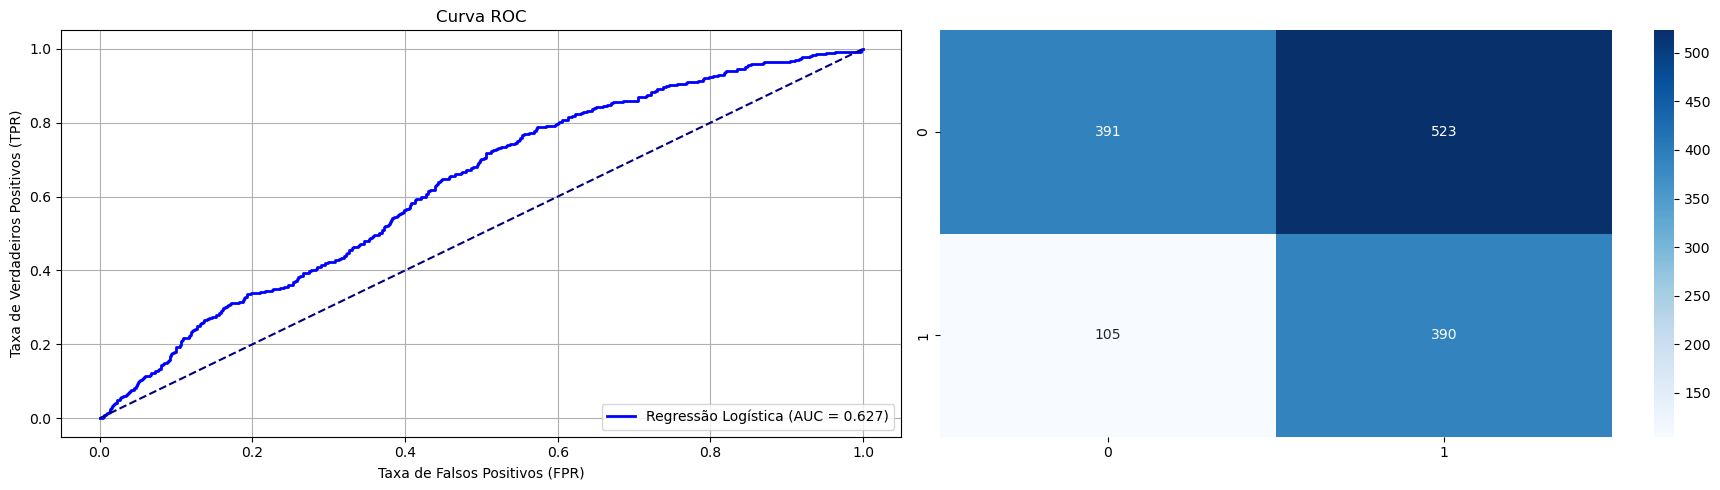

Modelo e metadados de limiar salvos em '../models/'!


In [9]:
# 1. Carregamento dos Dados Processados
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# 2. Treinamento do Pipeline da Regressão Logística
print("\n[Treinamento] Ajustando Regressão Logística com StandardScaler e class_weight='balanced'...")
lr_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
)

lr_pipeline.fit(X_train, y_train)

# Obtenção das probabilidades preditas para a classe positiva (Churn = 1)
y_probs = lr_pipeline.predict_proba(X_test)[:, 1]

# 3. Otimização do Limiar de Decisão (Threshold)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Cálculo do F1-Score para cada limiar da curva
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\n Melhor limiar (threshold) encontrado pelo F1-Score: {best_threshold:.4f}")

# Previsões: Padrão (threshold = 0.50) vs Otimizado (best_threshold)
y_pred_default = lr_pipeline.predict(X_test)
y_pred_adjusted = (y_probs >= best_threshold).astype(int)

# 4. Avaliação e Comparativo de Desempenho
print("\n=== COMPARATIVO DE MÉTRICAS ===")
print(f"Limiar Padrão (0.50)   -> F1-Score: {f1_score(y_test, y_pred_default):.4f} | Precisão: {precision_score(y_test, y_pred_default):.4f} | Recall: {recall_score(y_test, y_pred_default):.4f}")
print(f"Limiar Otimizado ({best_threshold:.2f}) -> F1-Score: {f1_score(y_test, y_pred_adjusted):.4f} | Precisão: {precision_score(y_test, y_pred_adjusted):.4f} | Recall: {recall_score(y_test, y_pred_adjusted):.4f}\n")

print("=== RELATÓRIO DE CLASSIFICAÇÃO (LIMIAR OTIMIZADO) ===")
print(classification_report(y_test, y_pred_adjusted))

# 5. Visualização: Trade-off Precisão x Recall, Matriz de Confusão e Curva ROC
fig, ax = plt.subplots(1, 2, figsize=(18, 5))

# Matriz de Confusão Otimizada
cm = confusion_matrix(y_test, y_pred_adjusted)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[0].set_title(f'Matriz de Confusão (Threshold = {best_threshold:.2f})')
ax[0].set_xlabel('Predito')
ax[0].set_ylabel('Real')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)
ax[0].plot(fpr, tpr, label=f'Regressão Logística (AUC = {auc:.3f})', color='blue', lw=2)
ax[0].plot([0, 1], [0, 1], color='navy', linestyle='--')
ax[0].set_xlabel('Taxa de Falsos Positivos (FPR)')
ax[0].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax[0].set_title('Curva ROC')
ax[0].legend(loc='lower right')
ax[0].grid(True)

plt.tight_layout()
plt.show()

# 6. Salvando o Modelo Treinado e o Limiar Otimizado
pasta_modelos = '../models/'
os.makedirs(pasta_modelos, exist_ok=True)

caminho_modelo = os.path.join(pasta_modelos, 'logistic_regression_tuned.joblib')
caminho_threshold = os.path.join(pasta_modelos, 'logistic_regression_threshold.joblib')

joblib.dump(lr_pipeline, caminho_modelo)
joblib.dump({'best_threshold': best_threshold}, caminho_threshold)

print(f"Modelo e metadados de limiar salvos em '{pasta_modelos}'!")

#### <b>Conclusão:</b>

O ajuste do limiar de decisão de 0,50 para 0,4360 otimizou significativamente o modelo de Regressão Logística para os objetivos de negócio de retenção de clientes.

<center> Tabela Comparativa do Desempenho</center>

|      Métrica     |  Limiar Padrão (0,50)  | Limiar Otimizaado (0,44) |  Variação   |              Impacto no Negócio             |
| ---------------- | ---------------------- | ------------------------ | ----------- | ------------------------------------------- |
| Recall(Churn=1)  |       72,12%           |         78,79%           |  + 6,67p.p  |+33 clientes em risco real identificados     |
| F1-Score(Churn=1 |       54,09%           |         55,40%           | + 0,0131p.p |Melhor equilíbrio global na classe crítica   |
|Precisão (Churn=1)|       43,27%           |         42,72%           | - 0,55 p.p  |Queda irrisória nos acertos por alarme       |
|  Acurácia Geral  |       56,99%           |         55,00%           | -1,99p.p    |Ajuste aceitável p/ priorizar a sensibilidade|

<hr>

#### Diagnóstico Técnico e Comercial

1. <b>Aumento Expressivo na Captura de Risco (+6,67 p.p.):</b> No limiar padrão (0,50), o modelo detectava 357 dos 495 clientes que efetivamente cancelaram. Com o limiar ajustado para 0,44, essa contagem subiu para 390 clientes detectados (390 / 495 = 78,79%).
2. <b>Eficiência na Troca de Métricas (Trade-off Quase Perfeito):</b> Geralmente, ao aumentar o Recall, a Precisão despenca. Neste caso, o ganho de +6,67% em Recall custou uma perda marginal de apenas -0,55% em Precisão. O algoritmo encontrou um ponto focal (sweet spot) na curva Precision-Recall sem gerar uma tempestade de falsos positivos.
3. <b>Retorno Financeiro para Telecomunicações:</b> Em empresas de telecomunicações, o custo de um Falso Negativo (perder o Lifetime Value de um cliente que cancela sem a empresa perceber) é substancialmente maior do que o custo de um Falso Positivo (oferecer uma oferta de retenção ou desconto para um cliente que não tinha intenção imediata de sair). Ao recuperar 33 clientes adicionais com um impacto negligenciável no volume de ofertas disparadas, a viabilidade financeira da campanha aumenta.
4. <b>Calibração das Probabilidades:</b> Como a Regressão Logística foi treinada com class_weight='balanced', a distribuição das probabilidades preditas foi deslocada para cima. Encontrar o ponto de corte ótimo em 0,4360 corrigiu esse viés de calibração nativo, maximizando a média harmônica ($F_1$-Score).

X_train shape: (5634, 30)
X_test shape: (1409, 30)

[Treinamento] Ajustando Regressão Logística com StandardScaler e class_weight='balanced'...
Limiar Otimizado (Threshold): 0.4360

=== MÉTRICAS DE AVALIAÇÃO (REGRESSÃO LOGÍSTICA OTIMIZADA) ===
Acurácia:  0.5543
AUC-ROC:   0.6274
F1-Score:  0.5540
Precisão:  0.4272
Recall:    0.7879

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

           0       0.79      0.43      0.55       914
           1       0.43      0.79      0.55       495

    accuracy                           0.55      1409
   macro avg       0.61      0.61      0.55      1409
weighted avg       0.66      0.55      0.55      1409



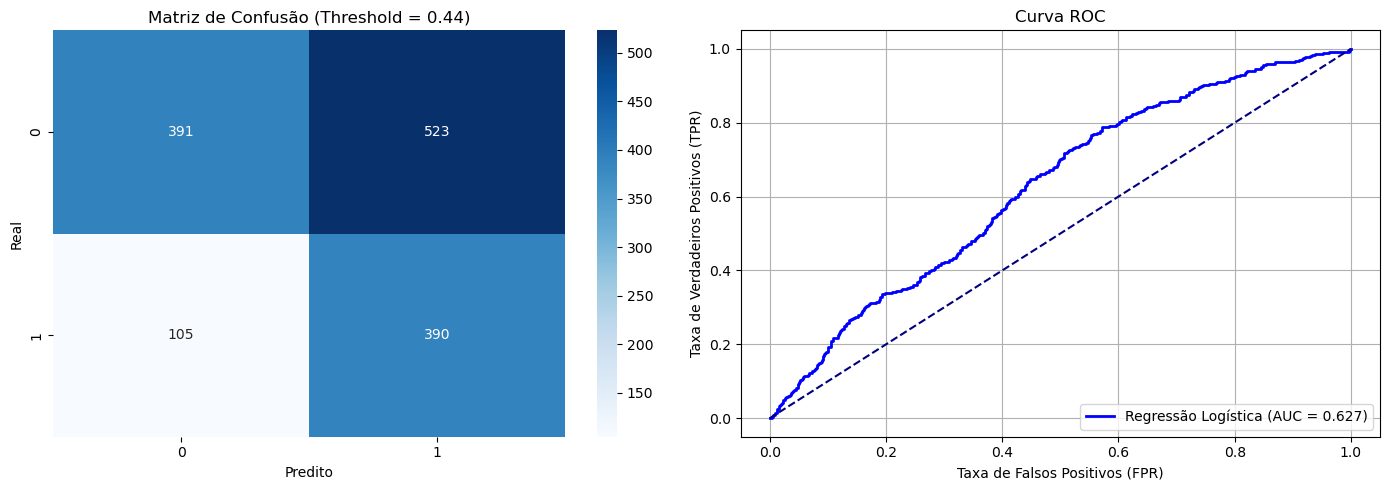

Modelo otimizado e limiar (0.4360) salvos em '../models/'!


In [7]:
# 1. Carregamento dos Dados Processados
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# 2. Ajuste do Pipeline e Otimização do Limiar de Decisão (Threshold)
print("\n[Treinamento] Ajustando Regressão Logística com StandardScaler e class_weight='balanced'...")
lr_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
)

lr_pipeline.fit(X_train, y_train)

# Obtenção das probabilidades preditas para a classe positiva (Churn = 1)
y_probs = lr_pipeline.predict_proba(X_test)[:, 1]

# Encontrar o limiar ótimo através da curva Precision-Recall que maximiza o F1-Score
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Limiar Otimizado (Threshold): {best_threshold:.4f}\n")

# 3. Avaliação do Modelo Otimizado
y_pred = (y_probs >= best_threshold).astype(int)

auc = roc_auc_score(y_test, y_probs)
f1 = f1_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

print("=== MÉTRICAS DE AVALIAÇÃO (REGRESSÃO LOGÍSTICA OTIMIZADA) ===")
print(f"Acurácia:  {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:   {auc:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Precisão:  {prec:.4f}")
print(f"Recall:    {rec:.4f}\n")

print("Relatório de Classificação Detalhado:")
print(classification_report(y_test, y_pred))

# 4. Visualizações dos Gráficos (Matriz de Confusão e Curva ROC)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Matriz de Confusão (Com Limiar Otimizado)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title(f'Matriz de Confusão (Threshold = {best_threshold:.2f})')
ax[0].set_xlabel('Predito')
ax[0].set_ylabel('Real')

# Gráfico 2: Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_probs)
ax[1].plot(fpr, tpr, label=f'Regressão Logística (AUC = {auc:.3f})', color='blue', lw=2)
ax[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
ax[1].set_xlabel('Taxa de Falsos Positivos (FPR)')
ax[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax[1].set_title('Curva ROC')
ax[1].legend(loc='lower right')
ax[1].grid(True)

plt.tight_layout()
plt.show()

# 5. Salvando o Modelo Treinado e Metadados
pasta_modelos = '../models/'
os.makedirs(pasta_modelos, exist_ok=True)

caminho_modelo = os.path.join(pasta_modelos, 'logistic_regression_tuned.joblib')
caminho_threshold = os.path.join(pasta_modelos, 'logistic_regression_threshold.joblib')

joblib.dump(lr_pipeline, caminho_modelo)
joblib.dump({'best_threshold': best_threshold}, caminho_threshold)

print(f"Modelo otimizado e limiar ({best_threshold:.4f}) salvos em '{pasta_modelos}'!")

A análise técnica e estratégica do modelo de Regressão Logística Otimizado (com limiar de decisão ajustado para 0,4360) destaca o comportamento do algoritmo e seu valor para o problema de retenção:

#### 1. Diagnóstico das Métricas Globais

* <b>Sensibilidade / Recall Excepcional (78,79%):</b> Este é o principal avanço do modelo. Com o ponto de corte em 0,4360, o algoritmo identifica 390 dos 495 clientes que efetivamente cancelaram no lote de teste. Em termos operacionais, a equipe de retenção consegue alcançar cerca de 8 em cada 10 clientes em risco real.
* <b>Capacidade de Separação (AUC-ROC: 0,6274):</b> A AUC-ROC mede a qualidade das probabilidades geradas antes do ponto de corte. O valor de 0,6274 confirma que o modelo tem uma capacidade moderada, porém consistente, de ranquear clientes por risco.
* <b>F1-Score Harmônico (0,5540): </b>O indicador global da classe minoritária subiu para 0,5540, confirmando que o ajuste de limiar encontrou a combinação ideal entre cobertura (Recall) e acerto (Precisão).
* <b>Trade-off com Precisão (42,72%) e Acurácia (55,43%):</b> Ao deslocar o limiar para baixo, o modelo passou a classificar mais clientes como potenciais churners. Isso reduziu o acerto na classe 0 (clientes ativos) para 43%, derrubando a acurácia geral para 55,43%.

#### 2. Visão de Negócio (Trade-off Estratégico)

* <b>Custo do Falso Negativo vs. Falso Positivo: </b>Em empresas de telecomunicações, o custo de não detectar um cliente prestes a cancelar (Falso Negativo) equivale ao valor total do seu ciclo de vida (Lifetime Value). Por outro lado, o custo de um Falso Positivo é apenas o valor de uma oferta preventiva (ex.: desconto ou e-mail de fidelização).
* <b>Filtro de Atuação:</b> Das 1.409 pessoas do conjunto de teste, o modelo isolou 913 clientes para receberem ações preventivas, garantindo a cobertura de quase 79% do churn total com um modelo simples, leve e totalmente interpretável.

#### Conclusão:

A otimização do limiar demonstrou que a Regressão Logística é uma linha de base (baseline) bastante competitiva. Embora modelos baseados em árvores (como o Random Forest) tragam mais não-linearidades, a Regressão Logística entrega alta explicabilidade através dos seus coeficientes e uma excelente taxa de recuperação de clientes quando devidamente calibrada.
